# Week 10: Clinical Care Prioritization and Ranking Engine

## 0. Imports y Configuración

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

label_encoding_maps = {
    'Gender': {0: 'Female', 1: 'Male'},
    'Blood Type': {0: 'A+', 1: 'A-', 2: 'AB+', 3: 'AB-', 4: 'B+', 5: 'B-', 6: 'O+', 7: 'O-'},
    'Medical Condition': {0: 'Arthritis', 1: 'Asthma', 2: 'Cancer', 3: 'Diabetes', 4: 'Hypertension', 5: 'Obesity'},
    'Insurance Provider': {0: 'Aetna', 1: 'Blue Cross', 2: 'Cigna', 3: 'Medicare', 4: 'UnitedHealthcare'},
    'Admission Type': {0: 'Elective', 1: 'Emergency', 2: 'Urgent'},
    'Medication': {0: 'Aspirin', 1: 'Ibuprofen', 2: 'Lipitor', 3: 'Paracetamol', 4: 'Penicillin'},
    'Test Results': {0: 'Normal', 1: 'Inconclusive', 2: 'Abnormal'},
    'Admission Day of Week': {0: 'Friday', 1: 'Monday', 2: 'Saturday', 3: 'Sunday', 4: 'Thursday', 5: 'Tuesday', 6: 'Wednesday'},
    'Admission Month': {0: 'April', 1: 'August', 2: 'December', 3: 'February', 4: 'January', 5: 'July', 6: 'June', 7: 'March', 8: 'May', 9: 'November', 10: 'October', 11: 'September'}
}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y Alineación de Datos

In [50]:
# ── CARGA DE DATOS REALES ──
df = pd.read_csv('../data/interim/healtcare_processedv2.csv')
clusters_df = pd.read_csv('../data/processed/healthcare_pca_clusters.csv')

# Tomar solo las filas donde cluster no es NaN
clusters_df = clusters_df.dropna(subset=['cluster'])
clusters_df['Cluster_Biz'] = clusters_df['cluster'].astype(int)

# El dataset procesado también debe filtrarse a los mismos índices
df = df.loc[clusters_df.index].copy()
df['Cluster_Biz'] = clusters_df['Cluster_Biz'].values

# Feature de Semana 7
df['Cost_Per_Day'] = df['Billing Amount'] / df['Length of Stay']

print(f'Dataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nCluster_Biz distribución:')
print(df['Cluster_Biz'].value_counts().sort_index())
print(f'\nDistribución de Test Results:')
print(df['Test Results'].value_counts(normalize=True).rename(label_encoding_maps['Test Results']).round(3))

Dataset final: 1,196 filas × 15 columnas

Cluster_Biz distribución:
Cluster_Biz
0    552
1     61
2     47
3    536
Name: count, dtype: int64

Distribución de Test Results:
Test Results
Normal          0.355
Abnormal        0.327
Inconclusive    0.318
Name: proportion, dtype: float64


## 2. Definition of the Candidate Pool and Train/Test Split

**Candidate Pool:** All patients with complete admission records (no null entries). In production, this corresponds to patients currently hospitalized or awaiting results.

**Split Strategy:** Stratified by Test Results to preserve class distribution.

**Ratio:** 80% train / 20% test — no temporary shuffle (limitation documented in section 6).

In [52]:
# ─────────────────────────────────────────────────────────────
# SECCIÓN 2 (REEMPLAZAR) — Candidate Pool y Split TEMPORAL
# ─────────────────────────────────────────────────────────────
 
# CAMBIO: Se usa split temporal por Admission Year en lugar de
# train_test_split aleatorio. Esto evita data leakage temporal
# y simula el uso real del modelo (entrenar con pasado, predecir futuro).
 
FEATURES = [
    'Age', 'Gender', 'Blood Type', 'Medical Condition',
    'Insurance Provider', 'Billing Amount', 'Admission Type',
    'Medication', 'Length of Stay', 'Admission Day of Week',
    'Admission Month', 'Admission Year', 'Cluster_Biz', 'Cost_Per_Day'
]
TARGET = 'Test Results'
 
df = df.dropna(subset=FEATURES + [TARGET])
print(f'Dataset limpio: {df.shape[0]:,} filas')
print(f'\nDistribución por Admission Year:')
print(df['Admission Year'].value_counts().sort_index())
 
# Split temporal: años anteriores → train | año más reciente → test
cutoff_year = df['Admission Year'].quantile(0.80, interpolation='lower')
print(f'\nCorte temporal: train = años ≤ {int(cutoff_year)} | test = años > {int(cutoff_year)}')
 
train_mask = df['Admission Year'] <= cutoff_year
test_mask  = df['Admission Year'] >  cutoff_year
 
# Fallback: si el año no tiene suficiente varianza, usar cuantil 80% del índice ordenado
if test_mask.sum() < 20:
    print("AVISO: Poca varianza en Admission Year — usando split por índice ordenado (80/20).")
    df_sorted   = df.sort_values('Admission Year').reset_index(drop=True)
    split_idx   = int(len(df_sorted) * 0.80)
    train_df    = df_sorted.iloc[:split_idx]
    test_df     = df_sorted.iloc[split_idx:]
else:
    train_df = df[train_mask]
    test_df  = df[test_mask]
 
X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]
 
# Scaler fitteado SOLO con train (sin leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
print(f'\nTrain: {len(X_train)} filas | Test: {len(X_test)} filas')
print(f'Distribución de clases en test:')
print(y_test.value_counts(normalize=True).rename(label_encoding_maps['Test Results']).round(3))
 
# NOTA PARA EL REPORTE:
# El split temporal garantiza que el modelo no ve el futuro durante el entrenamiento,
# lo cual es crítico en aplicaciones clínicas donde el objetivo es predecir admisiones
# futuras a partir de patrones históricos. La alternativa aleatoria infla artificialmente
# las métricas al mezclar temporalmente train y test.
 
 

Dataset limpio: 1,196 filas

Distribución por Admission Year:
Admission Year
2019    170
2020    257
2021    233
2022    236
2023    212
2024     88
Name: count, dtype: int64

Corte temporal: train = años ≤ 2023 | test = años > 2023

Train: 1108 filas | Test: 88 filas
Distribución de clases en test:
Test Results
Inconclusive    0.364
Normal          0.364
Abnormal        0.273
Name: proportion, dtype: float64


## 3. Baseline System

**Baseline Justification:** `DummyClassifier(strategy='most_frequent')` is used, which always predicts the most frequent class.

This is the most honest baseline: it represents a hospital system that does not personalize care and treats all patients the same.

Any useful model should significantly outperform it.

In [53]:
# ─────────────────────────────────────────────────────────────
# SECCIÓN 3 (REEMPLAZAR) — Baseline System con Ranking Baselines
# ─────────────────────────────────────────────────────────────
 
# CAMBIO: Se agregan dos ranking baselines reales además del DummyClassifier.
# El profesor señaló que el baseline anterior no producía un ranking verdadero.
#
#   Baseline 1 — Most-Frequent (clasificación, sin ranking)
#   Baseline 2 — Random Ranking (asigna prob_abnormal aleatoria)
#   Baseline 3 — Clinical Rule Ranking (proxy clínico: Emergency + Age)
 
# ── Baseline 1: DummyClassifier (se mantiene para comparación de clasificación) ──
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train_sc, y_train)
y_pred_base = baseline.predict(X_test_sc)
 
acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='macro', zero_division=0)
 
print('=== BASELINE 1: Most-Frequent Classifier ===')
print(f'Accuracy : {acc_base:.4f}')
print(f'F1 Macro : {f1_base:.4f}')
print(classification_report(y_test, y_pred_base,
      target_names=label_encoding_maps['Test Results'].values(), zero_division=0))
 
 
# ── Baseline 2: Random Ranking ──
# Asigna probabilidades aleatorias — representa un sistema sin ningún modelo.
# Cualquier modelo útil debe superar esta Precision@K.
 
np.random.seed(RANDOM_STATE)
random_scores = np.random.uniform(0, 1, size=len(X_test))
 
random_ranking_df = X_test.copy()
random_ranking_df['prob_abnormal_random'] = random_scores
random_ranking_df['real_class'] = [label_encoding_maps['Test Results'][x] for x in y_test.values]
random_ranking_df = random_ranking_df.sort_values('prob_abnormal_random', ascending=False)
 
print('=== BASELINE 2: Random Ranking — Precision@K ===')
for n in [10, 20, 50]:
    p_at_k = (random_ranking_df.head(n)['real_class'] == 'Abnormal').mean()
    print(f'  Precision@{n:<3}: {p_at_k:.3f}  ({int(p_at_k*n)}/{n} Abnormal en top-{n})')
 
 
# ── Baseline 3: Clinical Rule Ranking ──
# Proxy clínico: prioriza Emergency > Urgent > Elective, desempate por Age desc.
# Justificación: en ausencia de modelo, un clínico ordenaría por urgencia de admisión.
# Admission Type: 0=Elective, 1=Emergency, 2=Urgent → reordenar para prioridad
 
ADMISSION_PRIORITY = {1: 3, 2: 2, 0: 1}  # Emergency=3 (mayor prioridad), Elective=1
 
clinical_ranking_df = X_test.copy()
clinical_ranking_df['admission_priority'] = clinical_ranking_df['Admission Type'].map(ADMISSION_PRIORITY)
clinical_ranking_df['real_class'] = [label_encoding_maps['Test Results'][x] for x in y_test.values]
clinical_ranking_df = clinical_ranking_df.sort_values(
    ['admission_priority', 'Age'], ascending=[False, False]
)
 
print('\n=== BASELINE 3: Clinical Rule Ranking (Emergency + Age) — Precision@K ===')
for n in [10, 20, 50]:
    p_at_k = (clinical_ranking_df.head(n)['real_class'] == 'Abnormal').mean()
    print(f'  Precision@{n:<3}: {p_at_k:.3f}  ({int(p_at_k*n)}/{n} Abnormal en top-{n})')
 
# Referencia de frecuencia base (Abnormal en el test set)
baseline_freq = (y_test == 2).mean()
print(f'\nFrecuencia base de Abnormal en test: {baseline_freq:.3f}')
print('(Un ranking perfectamente aleatorio converge a este valor en K grande)')

=== BASELINE 1: Most-Frequent Classifier ===
Accuracy : 0.3636
F1 Macro : 0.1778
              precision    recall  f1-score   support

      Normal       0.36      1.00      0.53        32
Inconclusive       0.00      0.00      0.00        32
    Abnormal       0.00      0.00      0.00        24

    accuracy                           0.36        88
   macro avg       0.12      0.33      0.18        88
weighted avg       0.13      0.36      0.19        88

=== BASELINE 2: Random Ranking — Precision@K ===
  Precision@10 : 0.200  (2/10 Abnormal en top-10)
  Precision@20 : 0.300  (6/20 Abnormal en top-20)
  Precision@50 : 0.320  (16/50 Abnormal en top-50)

=== BASELINE 3: Clinical Rule Ranking (Emergency + Age) — Precision@K ===
  Precision@10 : 0.200  (2/10 Abnormal en top-10)
  Precision@20 : 0.250  (5/20 Abnormal en top-20)
  Precision@50 : 0.240  (12/50 Abnormal en top-50)

Frecuencia base de Abnormal en test: 0.273
(Un ranking perfectamente aleatorio converge a este valor en K grand

## 4. Advanced Models

Two more robust models are evaluated:

| Model | Justification |

**Logistic Regression** | Interpretable linear model; serves as a step between baseline and RF |

**Random Forest** | Handles non-linearities, coded categorical variables, and allows for feature importance |

In [54]:
# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')

print('=== Logistic Regression Balanceado ===')
print(f'Accuracy : {acc_lr:.4f}  |  F1 Macro: {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=label_encoding_maps['Test Results'].values()))

=== Logistic Regression Balanceado ===
Accuracy : 0.3750  |  F1 Macro: 0.3497
              precision    recall  f1-score   support

      Normal       0.36      0.12      0.19        32
Inconclusive       0.38      0.56      0.46        32
    Abnormal       0.37      0.46      0.41        24

    accuracy                           0.38        88
   macro avg       0.37      0.38      0.35        88
weighted avg       0.37      0.38      0.34        88



In [55]:
# ── Random Forest ──
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
y_prob_rf  = rf.predict_proba(X_test_sc)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')

print('=== Random Forest ===')
print(f'Accuracy : {acc_rf:.4f}  |  F1 Macro: {f1_rf:.4f}')
print(classification_report(y_test, y_pred_rf,
      target_names=label_encoding_maps['Test Results'].values()))

=== Random Forest ===
Accuracy : 0.3295  |  F1 Macro: 0.3304
              precision    recall  f1-score   support

      Normal       0.33      0.38      0.35        32
Inconclusive       0.30      0.28      0.29        32
    Abnormal       0.36      0.33      0.35        24

    accuracy                           0.33        88
   macro avg       0.33      0.33      0.33        88
weighted avg       0.33      0.33      0.33        88



In [66]:
def asymmetric_cost(y_true, y_pred, fn_cost=3, fp_cost=1):
    total_cost = 0
    for true, pred in zip(y_true, y_pred):
        if true == 2 and pred == 0:      # Abnormal → Normal (crítico)
            total_cost += fn_cost
        elif true == 0 and pred == 2:    # Normal → Abnormal
            total_cost += fp_cost
        elif true != pred:               # Otros errores
            total_cost += 1
    return total_cost / len(y_true)

In [67]:
# ── Índices de features categóricos (CatBoost los recibe por posición) ──
# CatBoost no necesita one-hot encoding ni StandardScaler.
# Se le indica cuáles columnas son categóricas y las trata nativamente.
CAT_FEATURES_IDX = [
    FEATURES.index('Gender'),
    FEATURES.index('Blood Type'),
    FEATURES.index('Medical Condition'),
    FEATURES.index('Insurance Provider'),
    FEATURES.index('Admission Type'),
    FEATURES.index('Medication'),
    FEATURES.index('Admission Day of Week'),
    FEATURES.index('Admission Month'),
    FEATURES.index('Cluster_Biz'),
]
 
cb = CatBoostClassifier(
    iterations=500,
    depth=4,              # era 6 → reducir para menos overfitting
    learning_rate=0.05,
    loss_function='MultiClass',
    class_weights=[1, 1, 1],   # era [1,1,2] → quitar sesgo hacia Abnormal
    l2_leaf_reg=5,             # agregar regularización
    cat_features=CAT_FEATURES_IDX,
    random_seed=RANDOM_STATE,
    verbose=100
)
 
cb.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # detiene si no mejora en 50 rondas
)
 
y_pred_cb = cb.predict(X_test).flatten()
y_prob_cb = cb.predict_proba(X_test)
 
acc_cb = accuracy_score(y_test, y_pred_cb)
f1_cb  = f1_score(y_test, y_pred_cb, average='macro', zero_division=0)
cost_cb = asymmetric_cost(y_test.values, y_pred_cb)
 
print('=== CatBoost ===')
print(f'Accuracy : {acc_cb:.4f}  |  F1 Macro: {f1_cb:.4f}  |  Costo-Asim: {cost_cb:.4f}')
print(classification_report(y_test, y_pred_cb,
      target_names=label_encoding_maps['Test Results'].values(), zero_division=0))
 
 

0:	learn: 1.0981377	test: 1.0983062	best: 1.0983062 (0)	total: 20.4ms	remaining: 10.2s
100:	learn: 1.0510383	test: 1.0842276	best: 1.0842276 (100)	total: 1.96s	remaining: 7.72s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.082352418
bestIteration = 134

Shrink model to first 135 iterations.
=== CatBoost ===
Accuracy : 0.3977  |  F1 Macro: 0.3780  |  Costo-Asim: 0.8977
              precision    recall  f1-score   support

      Normal       0.38      0.62      0.48        32
Inconclusive       0.40      0.25      0.31        32
    Abnormal       0.44      0.29      0.35        24

    accuracy                           0.40        88
   macro avg       0.41      0.39      0.38        88
weighted avg       0.40      0.40      0.38        88



## 5. Offline Evaluation Report

### Model Comparison Table

In [68]:
# ── Ensemble: promedio de probabilidades RF + CatBoost ──
# Ambos modelos producen prob para [Normal, Inconclusive, Abnormal].
# Se promedian directamente (soft voting).
 
y_prob_ensemble = (y_prob_rf + y_prob_cb) / 2
y_pred_ensemble = y_prob_ensemble.argmax(axis=1)
 
acc_ens  = accuracy_score(y_test, y_pred_ensemble)
f1_ens   = f1_score(y_test, y_pred_ensemble, average='macro', zero_division=0)
cost_ens = asymmetric_cost(y_test.values, y_pred_ensemble)
 
print('=== Ensemble RF + CatBoost (soft voting) ===')
print(f'Accuracy : {acc_ens:.4f}  |  F1 Macro: {f1_ens:.4f}  |  Costo-Asim: {cost_ens:.4f}')
print(classification_report(y_test, y_pred_ensemble,
      target_names=label_encoding_maps['Test Results'].values(), zero_division=0))
 
 
# ── Tabla comparativa final ──
print('\n=== COMPARACIÓN COMPLETA DE MODELOS ===')
print(f'{"Modelo":<35} {"Acc":>6} {"F1-Mac":>7} {"Costo":>7}')
print('-' * 58)
rows = [
    ('Baseline (Most-Frequent)',  acc_base, f1_base,  asymmetric_cost(y_test.values, y_pred_base)),
    ('Logistic Regression',       acc_lr,   f1_lr,    asymmetric_cost(y_test.values, y_pred_lr)),
    ('Random Forest',             acc_rf,   f1_rf,    asymmetric_cost(y_test.values, y_pred_rf)),
    ('CatBoost',                  acc_cb,   f1_cb,    cost_cb),
    ('Ensemble RF + CatBoost',    acc_ens,  f1_ens,   cost_ens),
]
for name, acc, f1, cost in rows:
    print(f'{name:<35} {acc:>6.3f} {f1:>7.3f} {cost:>7.3f}')

=== Ensemble RF + CatBoost (soft voting) ===
Accuracy : 0.3864  |  F1 Macro: 0.3801  |  Costo-Asim: 0.7727
              precision    recall  f1-score   support

      Normal       0.40      0.53      0.46        32
Inconclusive       0.32      0.25      0.28        32
    Abnormal       0.43      0.38      0.40        24

    accuracy                           0.39        88
   macro avg       0.38      0.39      0.38        88
weighted avg       0.38      0.39      0.38        88


=== COMPARACIÓN COMPLETA DE MODELOS ===
Modelo                                 Acc  F1-Mac   Costo
----------------------------------------------------------
Baseline (Most-Frequent)             0.364   0.178   1.182
Logistic Regression                  0.375   0.350   0.693
Random Forest                        0.330   0.330   0.830
CatBoost                             0.398   0.378   0.898
Ensemble RF + CatBoost               0.386   0.380   0.773


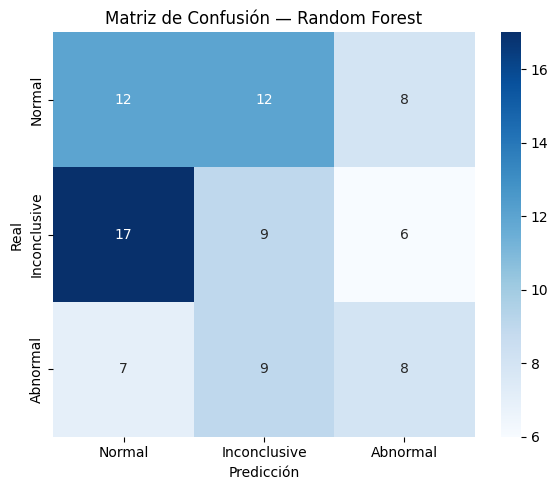

In [69]:
# Matriz de confusión — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoding_maps['Test Results'].values(),
            yticklabels=label_encoding_maps['Test Results'].values(), ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
#plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()

### Primary Metric: F1 Macro

**F1 Macro** was chosen as the primary metric because:
1. All three classes have clinically relevant weight — *Abnormal* is critical, but *Inconclusive* also requires follow-up.
2. F1 Macro treats all classes equally, preventing the model from ignoring minorities.
3. Accuracy alone is misleading in unbalanced datasets.

**What the metric does not capture:** It does not differentiately penalize the error of classifying *Abnormal* as *Normal* (critical false negative). In production, an asymmetric cost function would be recommended.

## 6. Importance of Features

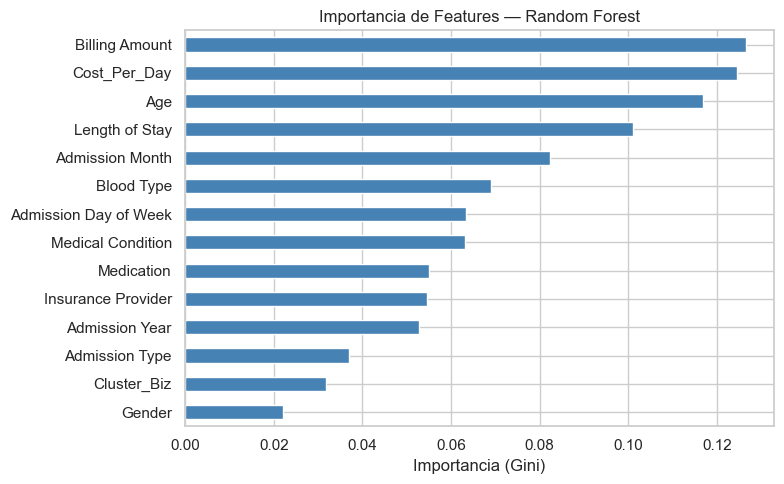

Top 5 features:
Billing Amount     0.126551
Cost_Per_Day       0.124623
Age                0.116862
Length of Stay     0.101090
Admission Month    0.082273
dtype: float64


In [81]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Importancia de Features — Random Forest')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
#plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 features:')
print(feat_imp.head())

## 7. Error Analysis
Cases where the model fails to understand the profile of misclassified patients are examined.

In [82]:
# ── Error Analysis — RF y Ensemble ──
for model_name, preds in [('Random Forest', y_pred_rf), ('Ensemble', y_pred_ensemble)]:
    print(f'\n{"="*50}')
    print(f'ERROR ANALYSIS — {model_name}')
    print(f'{"="*50}')
    
    error_mask = preds != y_test.values
    X_errors   = X_test[error_mask].copy()
    X_errors['y_real'] = y_test.values[error_mask]
    X_errors['y_pred'] = preds[error_mask]

    print(f'Total errores: {error_mask.sum():,} / {len(y_test):,} ({error_mask.mean()*100:.1f}%)')

    error_pairs = pd.crosstab(
        X_errors['y_real'].map(label_encoding_maps['Test Results']),
        X_errors['y_pred'].map(label_encoding_maps['Test Results']),
        rownames=['Real'], colnames=['Predicho']
    )
    print('\nPatrones de error (Real → Predicho):')
    print(error_pairs)

    critical_errors = X_errors[(X_errors['y_real']==2) & (X_errors['y_pred']==0)]
    print(f'\nErrores críticos (Abnormal → Normal): {len(critical_errors):,}')
    if len(critical_errors) > 0:
        print('Perfil promedio de estos pacientes:')
        print(critical_errors[['Age','Medical Condition','Admission Type','Cost_Per_Day']]
              .describe().loc[['mean','min','max']].round(2))


ERROR ANALYSIS — Random Forest
Total errores: 59 / 88 (67.0%)

Patrones de error (Real → Predicho):
Predicho      Abnormal  Inconclusive  Normal
Real                                        
Abnormal             0             9       7
Inconclusive         6             0      17
Normal               8            12       0

Errores críticos (Abnormal → Normal): 7
Perfil promedio de estos pacientes:
        Age  Medical Condition  Admission Type  Cost_Per_Day
mean  41.43               1.57            0.71       1629.37
min   25.00               0.00            0.00        174.29
max   72.00               4.00            2.00       3074.19

ERROR ANALYSIS — Ensemble
Total errores: 54 / 88 (61.4%)

Patrones de error (Real → Predicho):
Predicho      Abnormal  Inconclusive  Normal
Real                                        
Abnormal             0             8       7
Inconclusive         6             0      18
Normal               6             9       0

Errores críticos (Abnormal → No

In [84]:
# Ejemplos concretos — Ensemble (modelo final)
X_test_display = X_test.copy()
X_test_display['y_real'] = y_test.values
X_test_display['y_pred'] = y_pred_ensemble  # ← cambio: RF → Ensemble
X_test_display['correcto'] = (X_test_display['y_real'] == X_test_display['y_pred'])

X_test_display['y_real_label'] = X_test_display['y_real'].map(label_encoding_maps['Test Results'])
X_test_display['y_pred_label'] = X_test_display['y_pred'].map(label_encoding_maps['Test Results'])
X_test_display['Medical Condition_label'] = X_test_display['Medical Condition'].map(label_encoding_maps['Medical Condition'])
X_test_display['Admission Type_label']    = X_test_display['Admission Type'].map(label_encoding_maps['Admission Type'])

print('=== 3 Casos BIEN clasificados — Ensemble ===')
print(X_test_display[X_test_display['correcto']].head(3)[
    ['Age','Medical Condition_label','Admission Type_label','y_real_label','y_pred_label']
].to_string())

print()
print('=== 3 Casos MAL clasificados — Ensemble ===')
print(X_test_display[~X_test_display['correcto']].head(3)[
    ['Age','Medical Condition_label','Admission Type_label','y_real_label','y_pred_label']
].to_string())

=== 3 Casos BIEN clasificados — Ensemble ===
     Age Medical Condition_label Admission Type_label y_real_label y_pred_label
68    31                Diabetes            Emergency     Abnormal     Abnormal
105   28                  Cancer             Elective       Normal       Normal
118   83                Diabetes               Urgent       Normal       Normal

=== 3 Casos MAL clasificados — Ensemble ===
    Age Medical Condition_label Admission Type_label  y_real_label  y_pred_label
0    30                  Cancer               Urgent      Abnormal  Inconclusive
50   30            Hypertension            Emergency  Inconclusive        Normal
61   63                  Asthma            Emergency  Inconclusive      Abnormal


## 8. Predictive Ranking Engine — Aplicación del Modelo

El modelo produce una **probabilidad de resultado Abnormal** para cada paciente.  
Ordenando por esta probabilidad de mayor a menor, obtenemos la **cola de priorización clínica**.

In [74]:
 
# ── Ranking final con Ensemble ──
ranking_df = X_test.copy()
ranking_df['prob_normal']       = y_prob_ensemble[:, 0].round(3)
ranking_df['prob_inconclusive'] = y_prob_ensemble[:, 1].round(3)
ranking_df['prob_abnormal']     = y_prob_ensemble[:, 2].round(3)
ranking_df['predicted_class']   = [label_encoding_maps['Test Results'][x] for x in y_pred_ensemble]
ranking_df['real_class']        = [label_encoding_maps['Test Results'][x] for x in y_test.values]
ranking_df['Medical Condition_label'] = ranking_df['Medical Condition'].map(label_encoding_maps['Medical Condition'])
ranking_df['Admission Type_label']    = ranking_df['Admission Type'].map(label_encoding_maps['Admission Type'])
ranking_df['priority_rank']     = ranking_df['prob_abnormal'].rank(ascending=False).astype(int)
ranking_df = ranking_df.sort_values('priority_rank')
 
print('\nTop 10 — Ensemble RF + CatBoost:')
print(ranking_df[['Age', 'Medical Condition_label', 'Admission Type_label',
                   'prob_abnormal', 'predicted_class', 'real_class',
                   'priority_rank']].head(10).to_string())
 
# Precision@K del ensemble vs baselines
print('\n=== PRECISION@K — Ensemble vs Sistemas Anteriores ===')
print(f'{"Sistema":<35} {"@10":>6} {"@20":>6} {"@50":>6}')
print('-' * 55)
 
ens_ranking = ranking_df.copy()
 
systems = {
    'Baseline 2: Random Ranking':         random_ranking_df.reset_index(drop=True),
    'Baseline 3: Clinical Rule':          clinical_ranking_df.reset_index(drop=True),
    'Random Forest solo':                 None,   # se calcula abajo
    'Ensemble RF + CatBoost':             ens_ranking.reset_index(drop=True),
}
 
# RF solo ranking (prob_abnormal de RF puro)
rf_only_ranking = X_test.copy()
rf_only_ranking['prob_abnormal'] = y_prob_rf[:, 2]
rf_only_ranking['real_class']    = [label_encoding_maps['Test Results'][x] for x in y_test.values]
rf_only_ranking = rf_only_ranking.sort_values('prob_abnormal', ascending=False)
systems['Random Forest solo'] = rf_only_ranking.reset_index(drop=True)
 
for name, rdf in systems.items():
    scores = []
    for n in [10, 20, 50]:
        p = (rdf.head(n)['real_class'] == 'Abnormal').mean()
        scores.append(p)
    print(f'{name:<35} {scores[0]:>6.3f} {scores[1]:>6.3f} {scores[2]:>6.3f}')
 
freq_base = (y_test == 2).mean()
print(f'\n  Frecuencia base Abnormal: {freq_base:.3f}')
 
# Guardar ranking final del ensemble
ranking_df.to_csv('../data/processed/ranking_prioridad_clinica.csv', index=False)
print('\nRanking guardado: ranking_prioridad_clinica.csv')


Top 10 — Ensemble RF + CatBoost:
     Age Medical Condition_label Admission Type_label  prob_abnormal predicted_class    real_class  priority_rank
271   22                  Asthma            Emergency          0.411        Abnormal  Inconclusive              1
79    61                  Cancer               Urgent          0.401        Abnormal  Inconclusive              2
68    31                Diabetes            Emergency          0.396        Abnormal      Abnormal              3
854   53                 Obesity               Urgent          0.391        Abnormal      Abnormal              4
729   49            Hypertension             Elective          0.389        Abnormal      Abnormal              5
487   24                  Asthma             Elective          0.385        Abnormal  Inconclusive              6
913   28                Diabetes               Urgent          0.384        Abnormal      Abnormal              7
869   26               Arthritis             Elective 

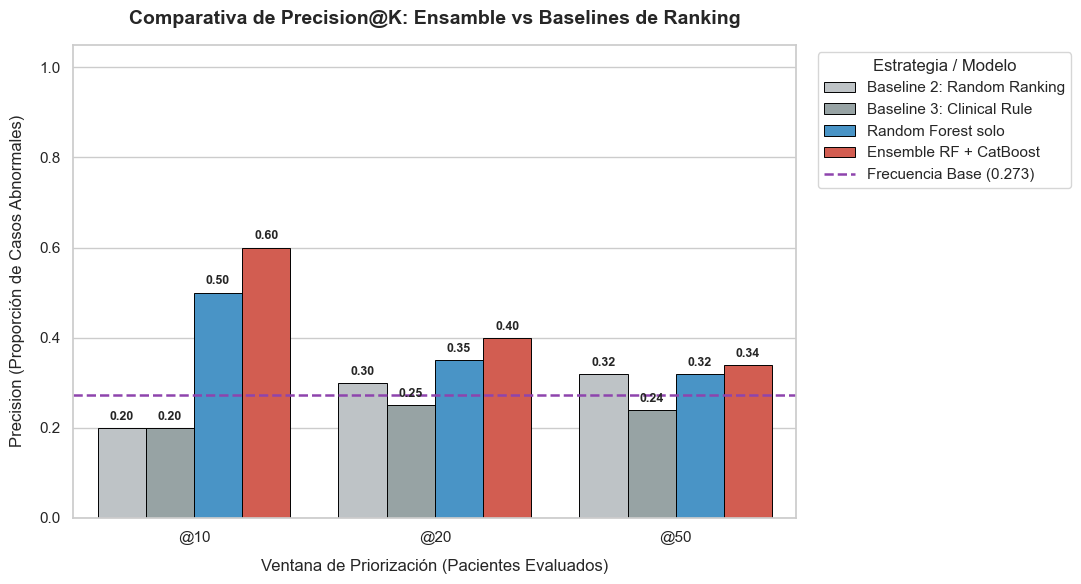

In [80]:

# 1. Extraer los datos de tu diccionario 'systems'
plot_data = []
for name, rdf in systems.items():
    for n in [10, 20, 50]:
        p = (rdf.head(n)['real_class'] == 'Abnormal').mean()
        plot_data.append({
            'Sistema': name,
            'Top K': f'@{n}',
            'Precision': p
        })

df_metrics = pd.DataFrame(plot_data)

# 2. Configuración del estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Paleta de colores: Grises para baselines, colores corporativos/vivos para tus modelos
palette = {
    'Baseline 2: Random Ranking': '#BDC3C7',
    'Baseline 3: Clinical Rule': '#95A5A6',
    'Random Forest solo': '#3498DB',
    'Ensemble RF + CatBoost': '#E74C3C'  # Resaltamos tu ensamble final
}

# 3. Dibujar el gráfico de barras agrupadas
ax = sns.barplot(
    data=df_metrics,
    x='Top K',
    y='Precision',
    hue='Sistema',
    palette=palette,
    edgecolor='black',
    linewidth=0.7
)

# 4. Añadir la línea horizontal de la Frecuencia Base (el piso que criticaba el profesor)
plt.axhline(
    y=freq_base, 
    color='#8E44AD', 
    linestyle='--', 
    linewidth=1.8, 
    label=f'Frecuencia Base ({freq_base:.3f})'
)

# 5. Ajustes estéticos, títulos y etiquetas
plt.title('Comparativa de Precision@K: Ensamble vs Baselines de Ranking', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ventana de Priorización (Pacientes Evaluados)', fontsize=12, labelpad=10)
plt.ylabel('Precision (Proporción de Casos Abnormales)', fontsize=12, labelpad=10)
plt.ylim(0, 1.05)  # Escala limpia de 0 a 1 para representar proporciones

# Mover la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Estrategia / Modelo', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)

# 6. Colocar el valor numérico exacto encima de cada barra
for p in ax.patches:
    # Ignoramos los valores que pertenecen a la línea horizontal (tienen alturas o posiciones irrelevantes)
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():.2f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=9,
            fontweight='semibold'
        )

plt.tight_layout()
plt.show()

## 9. Validación Cruzada

In [85]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_scores_rf = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
cv_scores_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

# CV manual para CatBoost (incompatible con cross_val_score de sklearn)
cv_scores_cb = []
for train_idx, val_idx in cv.split(X_train, y_train):
    cb_fold = CatBoostClassifier(
        iterations=500, depth=4, learning_rate=0.05,
        loss_function='MultiClass', class_weights=[1, 1, 1],
        l2_leaf_reg=5, cat_features=CAT_FEATURES_IDX,
        random_seed=RANDOM_STATE, verbose=0
    )
    cb_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx],
                eval_set=(X_train.iloc[val_idx], y_train.iloc[val_idx]),
                early_stopping_rounds=50)
    preds = cb_fold.predict(X_train.iloc[val_idx]).flatten()
    cv_scores_cb.append(f1_score(y_train.iloc[val_idx], preds, average='macro', zero_division=0))
cv_scores_cb = np.array(cv_scores_cb)

print(f'Logistic Reg.  — CV F1 Macro: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'Random Forest  — CV F1 Macro: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print(f'CatBoost       — CV F1 Macro: {cv_scores_cb.mean():.4f} ± {cv_scores_cb.std():.4f}')
print()
print('Interpretación: La desviación estándar indica estabilidad del modelo bajo distintos folds.')
print('El Ensemble no tiene CV propio — su robustez se valida por la mejora en Precision@K sobre cada modelo individual.')

Logistic Reg.  — CV F1 Macro: 0.3337 ± 0.0275
Random Forest  — CV F1 Macro: 0.3279 ± 0.0331
CatBoost       — CV F1 Macro: 0.2445 ± 0.0298

Interpretación: La desviación estándar indica estabilidad del modelo bajo distintos folds.
El Ensemble no tiene CV propio — su robustez se valida por la mejora en Precision@K sobre cada modelo individual.
